In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
 
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from scipy.stats import loguniform
import shap


c:\Users\prabh\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("WV_DCC.csv", skiprows=[1], low_memory=False) # Saved working version as csv and renamed to WV_DCC_v2.csv
df = df.drop(columns=['Unnamed: 0'])

In [3]:
drop_cols = ['Y','X12','X13','X14','X15','X16','X17']

X = df.drop(columns=drop_cols)
y = df['Y']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [7]:
y_pred = svm_model.predict(X_test_scaled)
y_prob = svm_model.predict_proba(X_test_scaled)[:, 1]

In [8]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)

print("\nSVM Results")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {roc:.4f}")


SVM Results
Accuracy : 0.8177
Precision: 0.6667
Recall   : 0.3512
F1 Score : 0.4600
ROC AUC  : 0.7264


In [9]:
param_dist = {
    'C': loguniform(0.01, 100),
    'gamma': loguniform(0.0001, 1),
    'kernel': ['rbf', 'poly']
}

svm = SVC(probability=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=svm,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_scaled, y_train)

best_svm = random_search.best_estimator_

print("\nBest Parameters:")
print(random_search.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best Parameters:
{'C': np.float64(0.06788387912421222), 'gamma': np.float64(0.018655260217376828), 'kernel': 'rbf'}


In [10]:
y_pred_tuned = best_svm.predict(X_test_scaled)
y_prob_tuned = best_svm.predict_proba(X_test_scaled)[:, 1]

In [11]:
print("\nTuned SVM Results")
print(f"Accuracy : {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_tuned):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_tuned):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_tuned):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob_tuned):.4f}")


Tuned SVM Results
Accuracy : 0.8140
Precision: 0.6522
Recall   : 0.3406
F1 Score : 0.4475
ROC AUC  : 0.7172


In [12]:
threshold = 0.30
y_pred_adj = (y_prob_tuned >= threshold).astype(int)

print("\nThreshold at 0.30 Tuned SVM Results")
print(f"Accuracy : {accuracy_score(y_test, y_pred_adj):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_adj):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_adj):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_adj):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob_tuned):.4f}")


Threshold at 0.30 Tuned SVM Results
Accuracy : 0.8062
Precision: 0.5919
Recall   : 0.3979
F1 Score : 0.4759
ROC AUC  : 0.7172


In [13]:
thresholds = np.linspace(0.1, 0.9, 50)

best_threshold = 0
best_f1 = 0

for t in thresholds:
    y_pred_temp = (y_prob_tuned >= t).astype(int)
    f1 = f1_score(y_test, y_pred_temp)
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print(f"Best Threshold: {best_threshold:.3f}")
print(f"Best F1 Score: {best_f1:.4f}")

Best Threshold: 0.182
Best F1 Score: 0.5121


In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

y_pred_best = (y_prob_tuned >= best_threshold).astype(int)

print("\nOptimal Threshold Results")
print("--------------------------")
print(f"Threshold: {best_threshold:.3f}")
print(f"Accuracy : {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_best):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_best):.4f}")


Optimal Threshold Results
--------------------------
Threshold: 0.182
Accuracy : 0.8050
Precision: 0.5733
Recall   : 0.4627
F1 Score : 0.5121


In [15]:

X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

X_background = X_train_scaled_df.sample(100, random_state=42)

X_sample = X_test_scaled_df.sample(200, random_state=42)

def svm_predict_proba(X):
    return best_svm.predict_proba(X)[:, 1]

explainer = shap.KernelExplainer(svm_predict_proba, X_background)

shap_vals = explainer.shap_values(X_sample, nsamples=100)

if isinstance(shap_vals, list):
    shap_vals_class1 = shap_vals[1]
else:
    shap_vals_class1 = shap_vals

shap_explanation_class1 = shap.Explanation(
    values=shap_vals_class1,
    base_values=np.repeat(explainer.expected_value, X_sample.shape[0]),
    data=X_sample.values,
    feature_names=X_sample.columns.tolist()
)

100%|██████████| 200/200 [16:18<00:00,  4.89s/it]


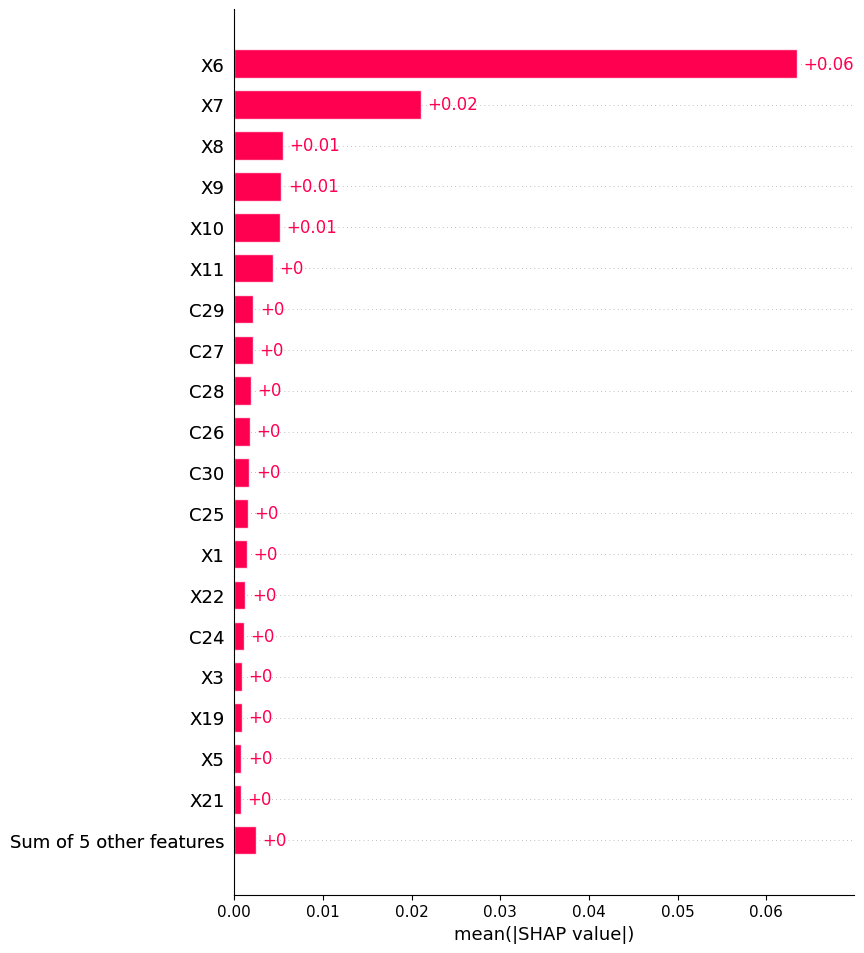

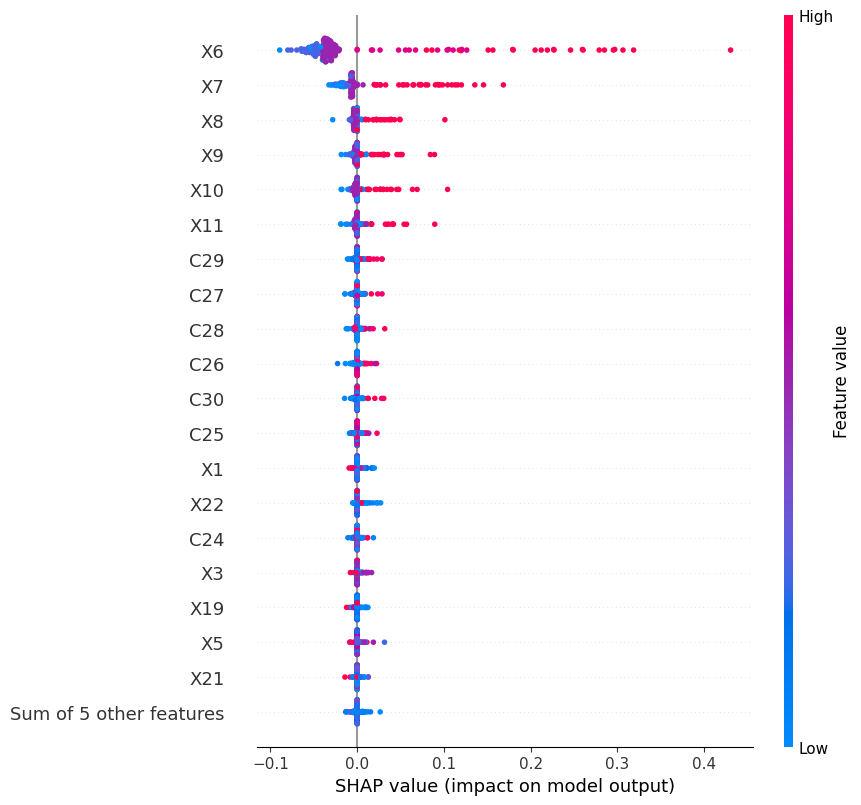

In [16]:
shap.plots.bar(
    shap_explanation_class1,
    max_display=20,
    show=True
)

shap.plots.beeswarm(
    shap_explanation_class1,
    max_display=20,
    show=True
)


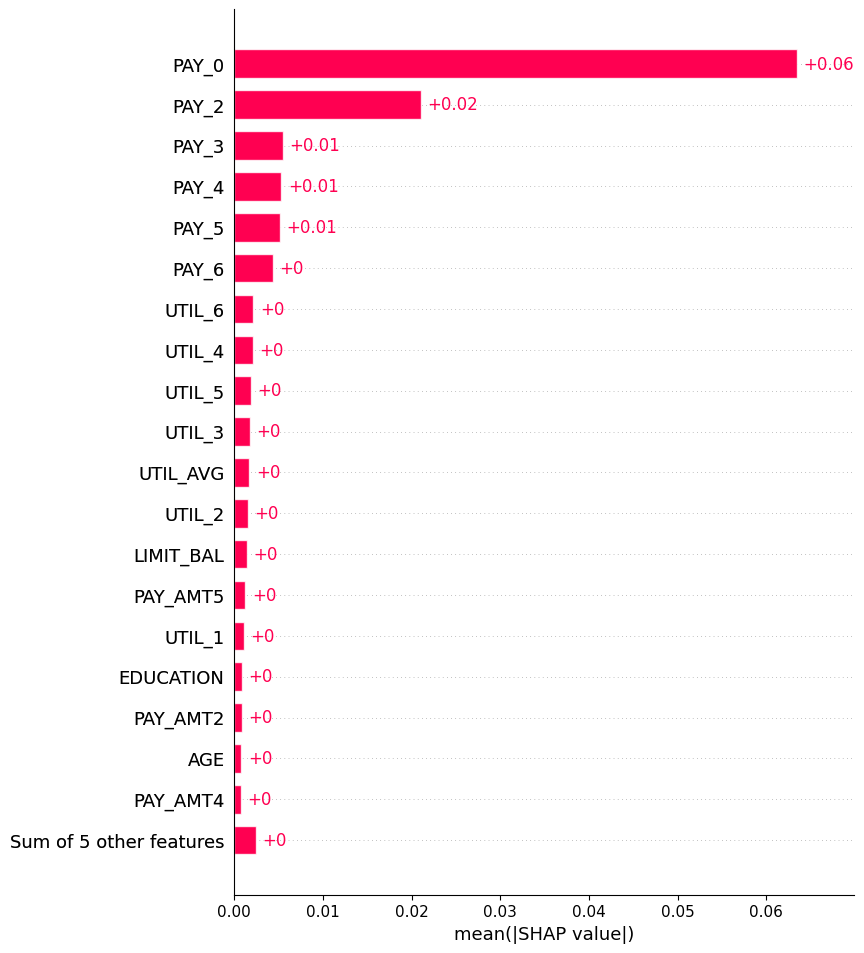

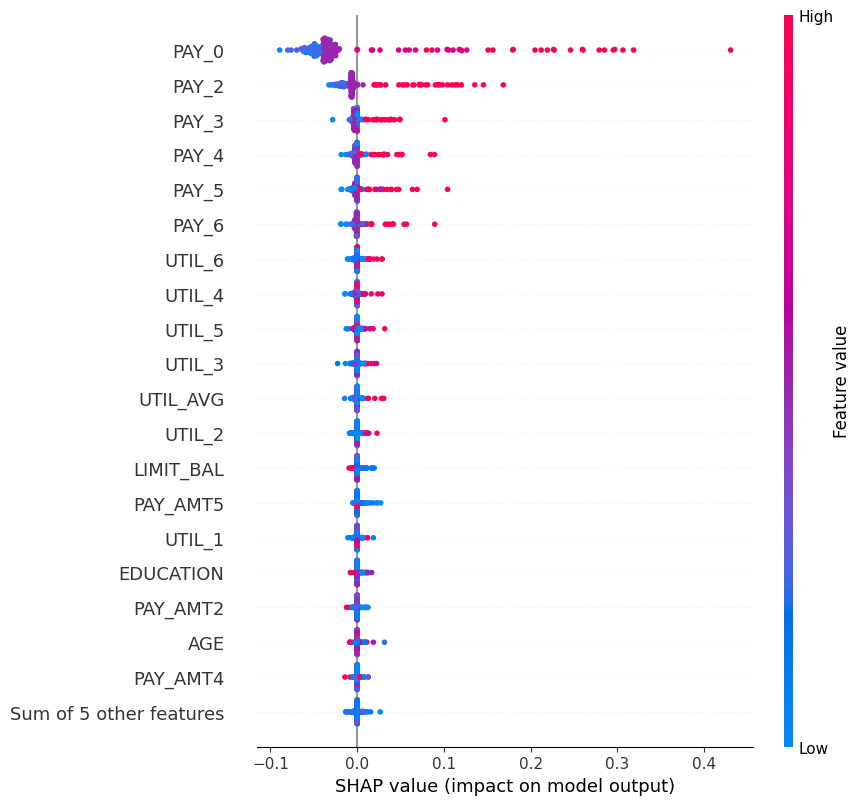

In [17]:
# Rename features for readable SHAP plot
feature_name_map = {
    'X1': 'LIMIT_BAL',
    'X2': 'SEX',
    'X3': 'EDUCATION',
    'X4': 'MARRIAGE',
    'X5': 'AGE',
    'X6': 'PAY_0',
    'X7': 'PAY_2',
    'X8': 'PAY_3',
    'X9': 'PAY_4',
    'X10': 'PAY_5',
    'X11': 'PAY_6',
    'X18': 'PAY_AMT1',
    'X19': 'PAY_AMT2',
    'X20': 'PAY_AMT3',
    'X21': 'PAY_AMT4',
    'X22': 'PAY_AMT5',
    'X23': 'PAY_AMT6',
    'C24': 'UTIL_1',
    'C25': 'UTIL_2',
    'C26': 'UTIL_3',
    'C27': 'UTIL_4',
    'C28': 'UTIL_5',
    'C29': 'UTIL_6',
    'C30': 'UTIL_AVG'
}

# Rename columns in sample
X_sample_named = X_sample.rename(columns=feature_name_map)

# Rebuild explanation
shap_explanation_named = shap.Explanation(
    values=shap_explanation_class1.values,
    base_values=shap_explanation_class1.base_values,
    data=X_sample_named.values,
    feature_names=X_sample_named.columns.tolist()
)

# Replot with readable names
shap.plots.bar(
    shap_explanation_named,
    max_display=20,
    show=True
)

shap.plots.beeswarm(
    shap_explanation_named,
    max_display=20,
    show=True
)